In [48]:
%reload_ext autoreload
%autoreload 2

In [642]:
import jax 
import jax.numpy as jnp

from jax.typing import ArrayLike
from typing import NamedTuple

import matplotlib.pyplot as plt

import flax.nnx as nnx

from probjax.nn.nets.transformer import  Transformer, MLP

In [643]:
def random_split_like_tree(rng_key, target=None, treedef=None):
    if treedef is None:
        treedef = jax.tree_structure(target)
    keys = jax.random.split(rng_key, treedef.num_leaves)
    return jax.tree_unflatten(treedef, keys)


def tree_random_normal_like(rng_key, target):
    keys_tree = random_split_like_tree(rng_key, target)
    return jax.tree_map(
        lambda l, k: jax.random.normal(k, l.shape, l.dtype),
        target,
        keys_tree,
    )

In [644]:
NUM_SAMPLES = 10


def generate_data(rng_key):
    rng_key_model, rng_key_params, rng_data = jax.random.split(rng_key,3)
    
    theta = jax.random.normal(rng_key_model, (1,)) * 2
    x = theta**2 + jax.random.normal(rng_key_params, (NUM_SAMPLES,))


    return theta, x
    

In [663]:
from models import ModelIdentificationDecoder, Simformer, EDM, ScalarTokenizer, VectorTokenizer, GaussianFourierEmbedding
import flax.nnx as nnx

tokenizer = ScalarTokenizer(1, value_dim=25, id_dim=25, cond_dim=0, context_dim=NUM_SAMPLES,rngs=nnx.Rngs(2))

model = EDM(Simformer(tokenizer, num_layers=4, rngs=nnx.Rngs(42)), std0=1.)


params = nnx.state(model, nnx.Param)

In [664]:
theta, x = generate_data(jax.random.PRNGKey(2))
theta.shape

(1,)

In [665]:
model(jnp.array([0.5]), theta[None,:], node_ids=jnp.arange(1), condition_mask=None,context=x[None,:])

Array([[0.733]], dtype=float32)

In [666]:
from probjax.nn.loss_fn.denoising import build_time_dependent_denoising_loss

def mean_fn(t, x):
    return x

def std_fn(t, x):
    return model.std_fn(t) 

denoiser_loss_fn = build_time_dependent_denoising_loss(model, mean_fn=mean_fn, std_fn=std_fn, weight_fn=model.weight_fn, axis=-2)

In [667]:
import optax


optimizer = optax.adam(5e-4)




def loss_fn(params,key):
    nnx.update(model, params)
    key1, key2 = jax.random.split(key)
    keys = jax.random.split(key1, (1000,))
    theta, xs = jax.vmap(generate_data)(keys)

    theta_flat = theta.reshape(-1,1,1)
    key_time, key_loss = jax.random.split(key2)
    logt = jax.random.normal(key_time, shape=(1000, 1,1)) * 1.2 - 1.2
    node_id = jnp.arange(1).reshape(1,-1).repeat(1000, axis=0)
    t = jnp.exp(logt) + 0.001


    loss = denoiser_loss_fn(params, t,theta_flat, node_ids=node_id, condition_mask=None,context=xs.reshape(-1,1,NUM_SAMPLES), rng=key_loss)
    return loss


@jax.jit
def update(params, key, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, key)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [668]:
params = nnx.state(model, nnx.Param)
key = jax.random.PRNGKey(0)
opt_state = optimizer.init(params)    

In [669]:
loss_fn(params,key)

Array(2.162, dtype=float32)

In [670]:

for i in range(50_000):
    key, subkey, key2 = jax.random.split(key, 3)
    loss, params, opt_state = update(params,subkey, opt_state)
    if (i % 500) == 0:
        print(loss)

2.0505657
0.653367
0.58626467
0.58365005
0.63853496
0.67077947
0.57345355
0.57935476
0.61590827
0.66310495
0.5554169
0.55576944
0.5293913
0.639399
0.5754081
0.68284816
0.53773725
0.64385283
0.63327765
0.61205786
0.6740692
0.7240791
0.68323565
0.6105583


KeyboardInterrupt: 

In [671]:
nnx.update(model, params)

In [672]:
from probjax.utils.odeint import odeint

def naive_diffusion_sampling(key, x_o):
    T_end = 10.
    rng_init, _ = jax.random.split(key)
    eps = jax.random.normal(rng_init, (1,)) * model.marginal_std(T_end)
    ts = jnp.linspace(0.01, T_end, 200)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        x_ = x.reshape((1,1,1))
        f = model.drift(t,x_)
        g = model.diffusion(t, x_)
        score = model.score(t,x_, node_ids=jnp.arange(1)[None,], condition_mask=None, context=x_o)
        backward_f = (f -0.5*g**2*score).reshape(x.shape)
        return backward_f

    return odeint(drift, eps,ts[::-1], method="heun")[-1]

In [673]:
theta, x_o = generate_data(jax.random.PRNGKey(0))

In [674]:
params_sampled = jax.vmap(lambda k: naive_diffusion_sampling(k, x_o[None,None,:]))(jax.random.split(jax.random.PRNGKey(1), 10000))

In [675]:
params_sampled.shape

(10000, 1)

In [676]:
def logdensity_fn(theta, x):
    logprior = jax.scipy.stats.norm.logpdf(theta, 0., 2.)
    loglikelihood = jax.scipy.stats.norm.logpdf(x,theta**2, 1.).sum(-1)
    return logprior + loglikelihood

thetas = jnp.linspace(-5,5,50_000)
logdensity = jax.vmap(lambda theta: logdensity_fn(theta, x_o))(thetas)
density = jnp.exp(logdensity - jnp.max(logdensity))
density_normalized = density / (jnp.trapezoid(density, thetas, axis=0) + 1e-6)


(-5.0, 5.0)

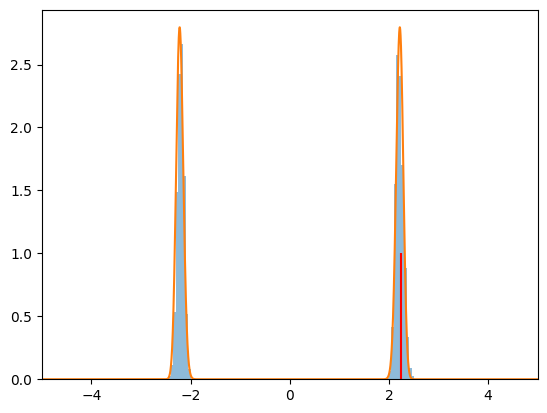

In [677]:
plt.hist(params_sampled.flatten(), bins=100, alpha=0.5, density=True)
plt.plot(thetas, density_normalized)
plt.vlines(theta, 0, 1, color="red")

plt.xlim(-5,5)

In [508]:

x_pred = jax.vmap(lambda key : f(samples_mask[0], key, prior_params(key)))(jax.random.split(jax.random.PRNGKey(0), 500))

NameError: name 'f' is not defined